In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve()))

In [3]:
import numpy as np
import pandas as pd
from skyfield.api import load

from starlink_uemr.config import load_yaml
from starlink_uemr.satellite.tle import build_timescale, load_satellite_from_tle, make_observer
from starlink_uemr.satellite.track import compute_topocentric_track, track_to_dataframe, filter_above_horizon
from starlink_uemr.geometry.washing import geometry_only_summary
from starlink_uemr.viz.tracks import plot_alt_track, plot_range_rate, plot_attenuation_heatmap

In [4]:
cfg = load_yaml("../configs/runs/exp00_geometry_only.yaml")
cfg

{'site': {'lat_deg': -30.7215, 'lon_deg': 21.4283, 'elev_m': 1050.0},
 'tle_path': '../data/raw/tle/starlink_sample.tle',
 'satellite_name': 'STARLINK',
 'time': {'start_jd': 2460400.25, 'n_times': 180, 'dt_sec': 10.0},
 'freq': {'start_hz': 110000000.0, 'stop_hz': 190000000.0, 'n_freqs': 256},
 'baseline': {'enu_m': [14.6, 0.0, 0.0]}}

In [5]:
ts = build_timescale()

start_jd = float(cfg["time"]["start_jd"])
n_times = int(cfg["time"]["n_times"])
dt_sec = float(cfg["time"]["dt_sec"])

# TLE epoch와 너무 멀면(>= 30일) SGP4 결과가 비정상일 수 있어 자동 보정
sat_preview = load.tle_file(cfg["tle_path"])[0]
tle_epoch_jd = float(sat_preview.model.jdsatepoch + sat_preview.model.jdsatepochF)

if abs(start_jd - tle_epoch_jd) > 30:
    print(f"[WARN] config start_jd={start_jd:.5f} is far from TLE epoch={tle_epoch_jd:.5f}")
    print("[WARN] start_jd is reset to TLE epoch for stable propagation")
    start_jd = tle_epoch_jd

jd_array = start_jd + np.arange(n_times) * dt_sec / 86400.0
times = ts.tt_jd(jd_array)

[WARN] config start_jd=2460400.25000 is far from TLE epoch=2461131.71435
[WARN] start_jd is reset to TLE epoch for stable propagation


In [6]:
sat = load_satellite_from_tle(cfg["tle_path"], cfg["satellite_name"])
observer = make_observer(
    cfg["site"]["lat_deg"],
    cfg["site"]["lon_deg"],
    cfg["site"]["elev_m"],
)

In [7]:
track = compute_topocentric_track(sat, observer, times)
track_all = track_to_dataframe(track)

n_above = int((track_all["alt_deg"] >= 0.0).sum())

# If nothing is above horizon, auto-find a visible Starlink pass nearby.
if n_above == 0:
    print("[info] no above-horizon samples in initial window; searching nearby visible pass...")

    satellites = load.tle_file(cfg["tle_path"])
    candidates = [s for s in satellites if "STARLINK" in s.name.upper()]

    scan_hours = 12
    scan_dt_sec = 60.0
    jd_scan = start_jd + np.arange(int(scan_hours * 3600 / scan_dt_sec)) * scan_dt_sec / 86400.0
    times_scan = ts.tt_jd(jd_scan)

    best_sat = None
    best_alt = -90.0
    best_peak_jd = None

    for s in candidates:
        alt_scan = (s - observer).at(times_scan).altaz()[0].degrees
        idx = int(np.argmax(alt_scan))
        alt_max = float(alt_scan[idx])
        if alt_max > best_alt:
            best_alt = alt_max
            best_sat = s
            best_peak_jd = float(jd_scan[idx])

    if best_sat is not None and best_alt > 0.0:
        window_sec = n_times * dt_sec
        start_jd = best_peak_jd - (window_sec / 2.0) / 86400.0
        jd_array = start_jd + np.arange(n_times) * dt_sec / 86400.0
        times = ts.tt_jd(jd_array)
        sat = best_sat

        track = compute_topocentric_track(sat, observer, times)
        track_all = track_to_dataframe(track)

        print(f"[info] switched to {sat.name} (peak alt ~ {best_alt:.2f} deg)")
        print(f"[info] recentered start_jd: {start_jd:.8f}")
    else:
        print("[warn] no visible Starlink pass found in scan window")

print("rows:", len(track_all))
print("alt min:", track_all["alt_deg"].min())
print("alt max:", track_all["alt_deg"].max())
print("n above horizon:", (track_all["alt_deg"] >= 0.0).sum())

track_all.head()

[info] no above-horizon samples in initial window; searching nearby visible pass...


[info] switched to STARLINK-34139 (peak alt ~ 89.39 deg)
[info] recentered start_jd: 2461131.91781883
rows: 180
alt min: -23.019371297933482
alt max: 89.39492969351522
n above horizon: 72


,jd,alt_deg,az_deg,range_km,range_rate_km_s,ux,uy,uz
0,2.461132e+06,-23.019371,238.888075,6070.935289,-6.186844,-0.787986,-0.475567,-0.391042
1,2.461132e+06,-22.663163,238.852362,6008.984824,-6.203266,-0.789755,-0.477307,-0.385313
2,2.461132e+06,-22.305826,238.816831,5946.870831,-6.219499,-0.791499,-0.479031,-0.379550
3,2.461132e+06,-21.947326,238.781479,5884.595705,-6.235542,-0.793219,-0.480741,-0.373754
4,2.461132e+06,-21.587620,238.746305,5822.161098,-6.251395,-0.794914,-0.482436,-0.367924


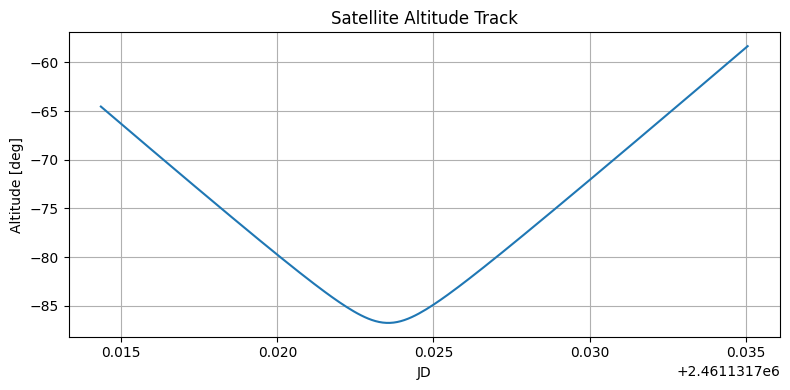

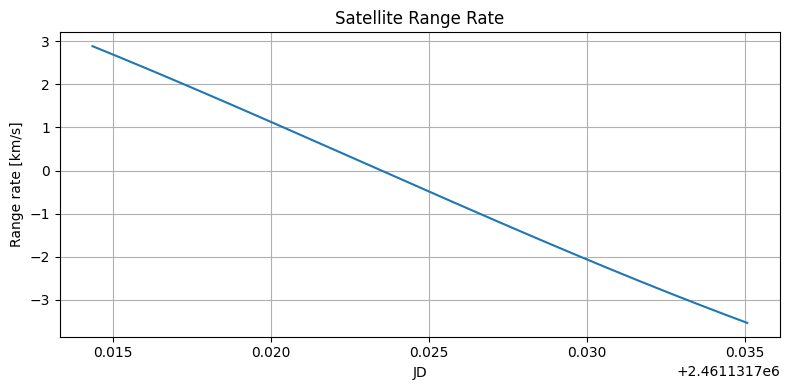

In [8]:
plot_alt_track(track_all)
plot_range_rate(track_all)

In [29]:
start_hz = float(cfg["freq"]["start_hz"])
stop_hz = float(cfg["freq"]["stop_hz"])
n_freqs = int(cfg["freq"]["n_freqs"])
baseline_enu_m = tuple(float(x) for x in cfg["baseline"]["enu_m"])

freqs_hz = np.linspace(start_hz, stop_hz, n_freqs)

track_df = filter_above_horizon(track_all, min_alt_deg=0.0)
print("filtered rows:", len(track_df))

summary = geometry_only_summary(
    track_df=track_df if len(track_df) > 0 else track_all,
    baseline_enu_m=baseline_enu_m,
    freqs_hz=freqs_hz,
    dt_sec=dt_sec,
)

filtered rows: 0


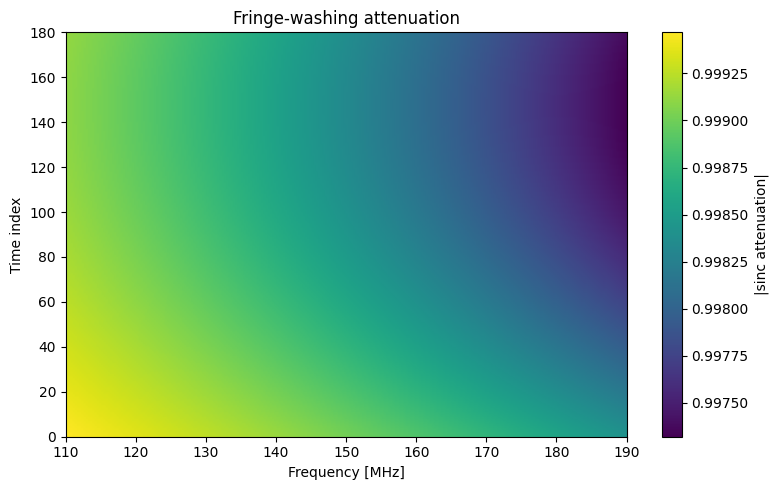

In [10]:
plot_attenuation_heatmap(summary)

문제 , starlink의 지평선 궤도 값이 음수임, 양수로 설정해줄거


In [30]:
# TLE 안의 Starlink를 빠르게 훑어 "가장 높이 뜨는 놈" 찾기


def scan_satellite_visibility(satellite, observer, ts, start_jd, hours=24, dt_sec=30.0):
    n_times = int(hours * 3600 / dt_sec)
    jd_array = start_jd + np.arange(n_times) * dt_sec / 86400.0
    times = ts.tt_jd(jd_array)

    topocentric = (satellite - observer).at(times)
    alt, az, distance = topocentric.altaz()

    alt_deg = alt.degrees
    best_idx = int(np.argmax(alt_deg))

    return {
        "name": satellite.name,
        "alt_max_deg": float(alt_deg[best_idx]),
        "jd_at_alt_max": float(jd_array[best_idx]),
        "idx_at_alt_max": best_idx,
    }


def _scan_candidates(candidates, observer, ts, start_jd, hours, dt_sec):
    rows = []
    for sat in candidates:
        try:
            rows.append(
                scan_satellite_visibility(
                    satellite=sat,
                    observer=observer,
                    ts=ts,
                    start_jd=start_jd,
                    hours=hours,
                    dt_sec=dt_sec,
                )
            )
        except Exception:
            rows.append(
                {
                    "name": sat.name,
                    "alt_max_deg": np.nan,
                    "jd_at_alt_max": np.nan,
                    "idx_at_alt_max": -1,
                }
            )
    return pd.DataFrame(rows)


def find_best_visible_satellite(
    tle_path,
    observer,
    ts,
    start_jd,
    keyword="STARLINK",
    # Fast coarse scan first
    coarse_hours=6,
    coarse_dt_sec=120.0,
    # Then refine only top candidates
    refine_hours=12,
    refine_dt_sec=60.0,
    top_k=30,
):
    satellites = load.tle_file(tle_path)
    candidates = [sat for sat in satellites if keyword.upper() in sat.name.upper()]

    print(f"Candidates: {len(candidates)}")
    print(f"Coarse scan: {coarse_hours}h @ {coarse_dt_sec:.0f}s")
    coarse_df = _scan_candidates(
        candidates=candidates,
        observer=observer,
        ts=ts,
        start_jd=start_jd,
        hours=coarse_hours,
        dt_sec=coarse_dt_sec,
    ).sort_values("alt_max_deg", ascending=False)

    top_df = coarse_df.head(top_k).copy()
    top_names = set(top_df["name"].tolist())
    top_candidates = [sat for sat in candidates if sat.name in top_names]

    print(f"Refine scan: top {len(top_candidates)} @ {refine_hours}h / {refine_dt_sec:.0f}s")
    refined_df = _scan_candidates(
        candidates=top_candidates,
        observer=observer,
        ts=ts,
        start_jd=start_jd,
        hours=refine_hours,
        dt_sec=refine_dt_sec,
    ).sort_values("alt_max_deg", ascending=False)

    # Keep refined top first, then the rest from coarse for visibility
    rest_df = coarse_df[~coarse_df["name"].isin(refined_df["name"])].copy()
    out_df = pd.concat([refined_df, rest_df], ignore_index=True)
    return out_df.reset_index(drop=True)


print("빠른 2단계 visibility 함수 정의 완료")

빠른 2단계 visibility 함수 정의 완료


In [22]:
# 실제로 검색 - 빠른 2단계 스캔 (with cache)

import pickle
from pathlib import Path

cache_path = Path("../data/processed/caches/vis_df_cache.pkl")
cache_path.parent.mkdir(parents=True, exist_ok=True)

if cache_path.exists():
    with open(cache_path, "rb") as f:
        vis_df = pickle.load(f)
    print(f"[cache] loaded: {cache_path}")
else:
    vis_df = find_best_visible_satellite(
        tle_path=cfg["tle_path"],
        observer=observer,
        ts=ts,
        start_jd=start_jd,
        keyword="STARLINK",
        coarse_hours=6,
        coarse_dt_sec=120.0,
        refine_hours=12,
        refine_dt_sec=60.0,
        top_k=30,
    )
    with open(cache_path, "wb") as f:
        pickle.dump(vis_df, f)
    print(f"[cache] saved: {cache_path}")

print("검색 완료 (cache-aware)")
print("Best 10:")
vis_df.head(10)

[cache] loaded: ../data/processed/caches/vis_df_cache.pkl
검색 완료 (cache-aware)
Best 10:


,name,alt_max_deg,jd_at_alt_max,idx_at_alt_max
0,STARLINK-34139,89.394930,2.461132e+06,308
1,STARLINK-34806,87.822966,2.461132e+06,228
2,STARLINK-4621,87.800649,2.461132e+06,196
3,STARLINK-35677,87.615120,2.461132e+06,172
4,STARLINK-35674,87.408987,2.461132e+06,292
5,STARLINK-35849,87.235946,2.461132e+06,182
6,STARLINK-5069,86.983390,2.461132e+06,128
7,STARLINK-35590,86.886479,2.461132e+06,176
8,STARLINK-33716,86.804097,2.461132e+06,252
9,STARLINK-30068,86.514509,2.461132e+06,250


In [23]:
# 제일 잘 보이는 위성 하나를 선택

best_row = vis_df.iloc[0]
print("Best satellite:")
print(best_row)

best_sat_name = best_row["name"]
peak_jd = float(best_row["jd_at_alt_max"])

print(f"\n선택: {best_sat_name}")
print(f"Peak JD: {peak_jd}")

Best satellite:
name              STARLINK-34139
alt_max_deg             89.39493
jd_at_alt_max     2461131.928235
idx_at_alt_max               308
Name: 0, dtype: object

선택: STARLINK-34139
Peak JD: 2461131.9282354987


In [24]:
# Peak 근처 30분 관측창으로 다시 재설정해서 track 생성

# exact name으로 다시 로드해서 scan 결과와 동일한 위성을 보장
satellites_all = load.tle_file(cfg["tle_path"])
sat_best = next((s for s in satellites_all if s.name == best_sat_name), None)
if sat_best is None:
    raise ValueError(f"Exact satellite name not found in TLE: {best_sat_name}")

# Pass peak을 중심으로 관측창 재설정
window_sec = n_times * dt_sec
start_jd_pass = peak_jd - (window_sec / 2) / 86400.0

jd_array_pass = start_jd_pass + np.arange(n_times) * dt_sec / 86400.0
times_pass = ts.tt_jd(jd_array_pass)

track_pass = compute_topocentric_track(sat_best, observer, times_pass)
track_all_pass = track_to_dataframe(track_pass).sort_values("jd").reset_index(drop=True)

print("Pass centered on peak:")
print(f"rows: {len(track_all_pass)}")
print(f"alt min: {track_all_pass['alt_deg'].min():.2f}")
print(f"alt max: {track_all_pass['alt_deg'].max():.2f}")
print(f"n above horizon: {(track_all_pass['alt_deg'] >= 0.0).sum()}")
print(f"is jd monotonic: {track_all_pass['jd'].is_monotonic_increasing}")
print()

track_all_pass.head()

Pass centered on peak:
rows: 180
alt min: -23.02
alt max: 89.39
n above horizon: 72
is jd monotonic: True



,jd,alt_deg,az_deg,range_km,range_rate_km_s,ux,uy,uz
0,2.461132e+06,-23.019371,238.888075,6070.935289,-6.186844,-0.787986,-0.475567,-0.391042
1,2.461132e+06,-22.663163,238.852362,6008.984824,-6.203266,-0.789755,-0.477307,-0.385313
2,2.461132e+06,-22.305826,238.816831,5946.870831,-6.219499,-0.791499,-0.479031,-0.379550
3,2.461132e+06,-21.947326,238.781479,5884.595705,-6.235542,-0.793219,-0.480741,-0.373754
4,2.461132e+06,-21.587620,238.746305,5822.161098,-6.251395,-0.794914,-0.482436,-0.367924


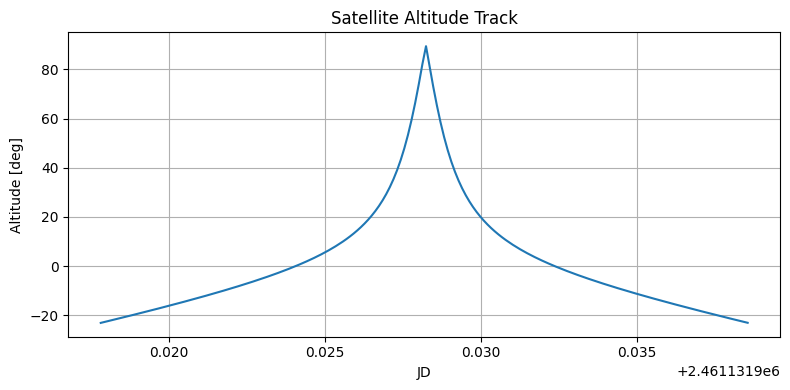

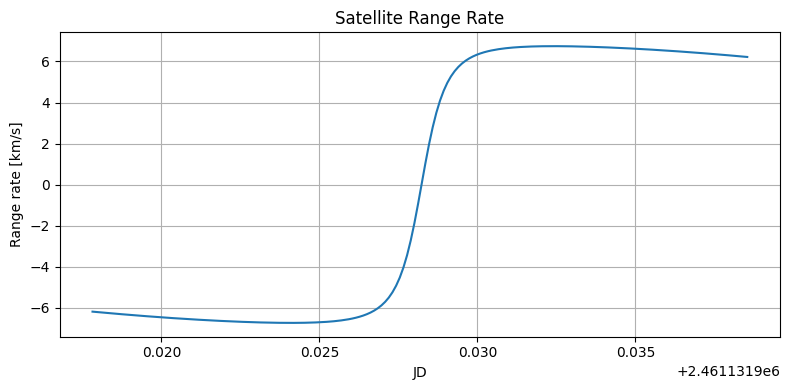

In [15]:
# 제대로 된 pass altitude 그래프

plot_alt_track(track_all_pass)
plot_range_rate(track_all_pass)

In [25]:
# Horizon 위의 샘플만 필터

track_df_pass = filter_above_horizon(track_all_pass, min_alt_deg=0.0)
print(f"filtered rows: {len(track_df_pass)}")
print(f"filtered / total: {len(track_df_pass)} / {len(track_all_pass)}")

track_df_pass.head()

filtered rows: 72
filtered / total: 72 / 180


,jd,alt_deg,az_deg,range_km,range_rate_km_s,ux,uy,uz
0,2.461132e+06,0.096173,237.181763,2545.868274,-6.734703,-0.840393,-0.541975,0.001679
1,2.461132e+06,0.709834,237.153479,2478.521953,-6.734479,-0.840062,-0.542349,0.012389
2,2.461132e+06,1.340870,237.125247,2411.181896,-6.733439,-0.839629,-0.542656,0.023400
3,2.461132e+06,1.990779,237.097059,2343.856346,-6.731510,-0.839085,-0.542890,0.034739
4,2.461132e+06,2.661224,237.068904,2276.555145,-6.728608,-0.838420,-0.543044,0.046430


short (14.6m)       : attenuation range [0.0000, 1.0000]
mid (50m)           : attenuation range [0.0001, 1.0000]
long (150m)         : attenuation range [0.0000, 1.0000]

=== short (14.6m) ===


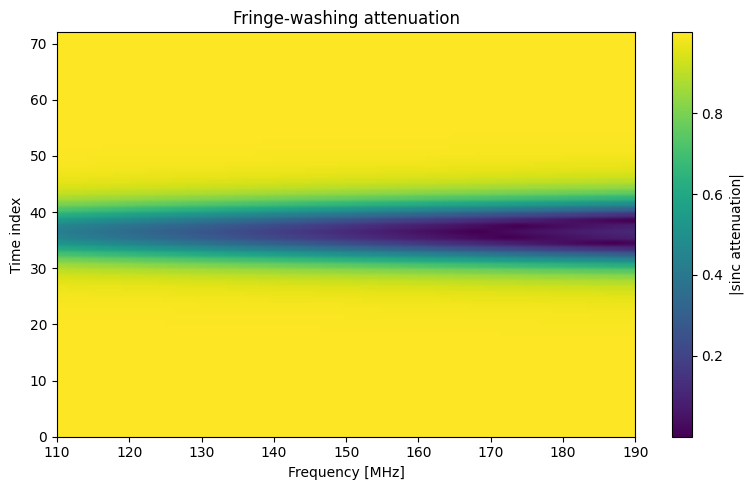


=== mid (50m) ===


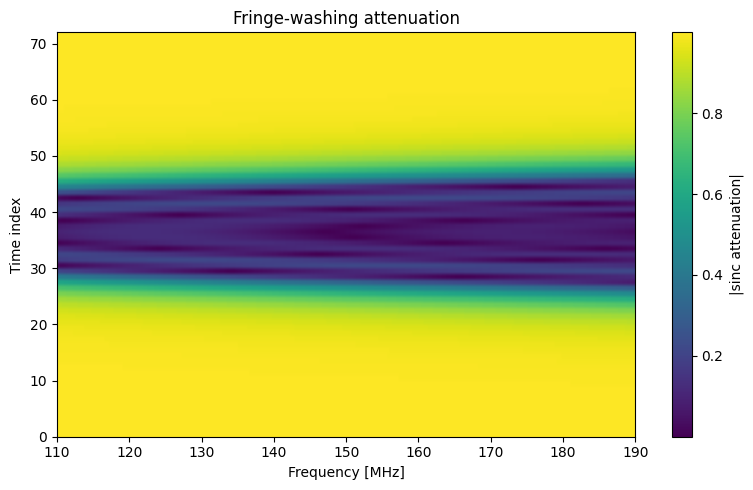


=== long (150m) ===


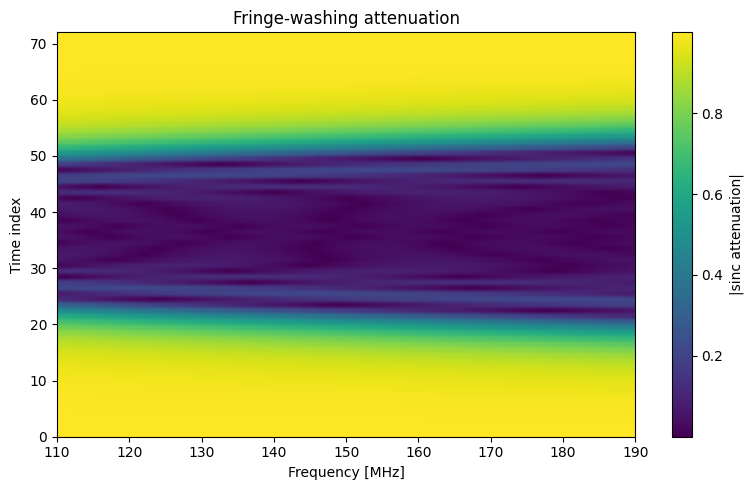

In [17]:
# 다양한 baseline으로 attenuation heatmap 비교

baseline_list = {
    "short (14.6m)": (14.6, 0.0, 0.0),
    "mid (50m)":     (50.0, 0.0, 0.0),
    "long (150m)":   (150.0, 0.0, 0.0),
}

results = {}
for label, bl in baseline_list.items():
    summary = geometry_only_summary(
        track_df=track_df_pass,
        baseline_enu_m=bl,
        freqs_hz=freqs_hz,
        dt_sec=dt_sec,
    )
    results[label] = summary
    
    att_min = summary["attenuation"].min()
    att_max = summary["attenuation"].max()
    print(f"{label:20s}: attenuation range [{att_min:.4f}, {att_max:.4f}]")

# Plot each
for label in baseline_list.keys():
    print(f"\n=== {label} ===")
    plot_attenuation_heatmap(results[label])

In [18]:
print("=== Sanity check ===")
print("alt min  :", track_all_pass["alt_deg"].min())
print("alt max  :", track_all_pass["alt_deg"].max())
print("range min:", track_all_pass["range_km"].min())
print("range max:", track_all_pass["range_km"].max())
print("rr min   :", track_all_pass["range_rate_km_s"].min())
print("rr max   :", track_all_pass["range_rate_km_s"].max())

=== Sanity check ===
alt min  : -23.019371297933482
alt max  : 89.39492969351522
range min: 489.44619406327115
range max: 6070.935288566485
rr min   : -6.7347028929741155
rr max   : 6.7453306581840815


In [19]:
rmin = track_all_pass["range_km"].min()
rmax = track_all_pass["range_km"].max()

if rmax > 10000:
    print("[warn] range가 너무 큼. TLE epoch / time window / satellite selection 다시 확인.")
else:
    print("[ok] range scale looks physically reasonable.")

[ok] range scale looks physically reasonable.


In [20]:
print("=== Sanity check ===")
print("alt min  :", track_all_pass["alt_deg"].min())
print("alt max  :", track_all_pass["alt_deg"].max())
print("range min:", track_all_pass["range_km"].min())
print("range max:", track_all_pass["range_km"].max())
print("rr min   :", track_all_pass["range_rate_km_s"].min())
print("rr max   :", track_all_pass["range_rate_km_s"].max())

=== Sanity check ===
alt min  : -23.019371297933482
alt max  : 89.39492969351522
range min: 489.44619406327115
range max: 6070.935288566485
rr min   : -6.7347028929741155
rr max   : 6.7453306581840815


In [21]:
rmin = track_all_pass["range_km"].min()
rmax = track_all_pass["range_km"].max()

if rmax > 10000:
    print("[warn] range가 너무 큼. TLE epoch / time window / satellite selection 다시 확인.")
else:
    print("[ok] range scale looks physically reasonable.")

[ok] range scale looks physically reasonable.


In [22]:
import numpy as np

freqs_hz = np.linspace(start_hz, stop_hz, n_freqs)

baseline_dict = {
    "short_14.6m": (14.6, 0.0, 0.0),
    "mid_50m":     (50.0, 0.0, 0.0),
    "long_150m":   (150.0, 0.0, 0.0),
}

track_vis_pass = track_all_pass[track_all_pass["alt_deg"] >= 0].reset_index(drop=True)

# fine scan에서 사용한 integration time fallback
dt_sec_fine = float(globals().get("dt_sec_fine", dt_sec))

summaries = {}
for name, bl in baseline_dict.items():
    summaries[name] = geometry_only_summary(
        track_df=track_vis_pass,
        baseline_enu_m=bl,
        freqs_hz=freqs_hz,
        dt_sec=dt_sec_fine,
    )

global_min = min(np.min(s["attenuation"]) for s in summaries.values())
global_max = max(np.max(s["attenuation"]) for s in summaries.values())

print("global vmin:", global_min)
print("global vmax:", global_max)

global vmin: 1.038976864574002e-05
global vmax: 0.9999999970054195


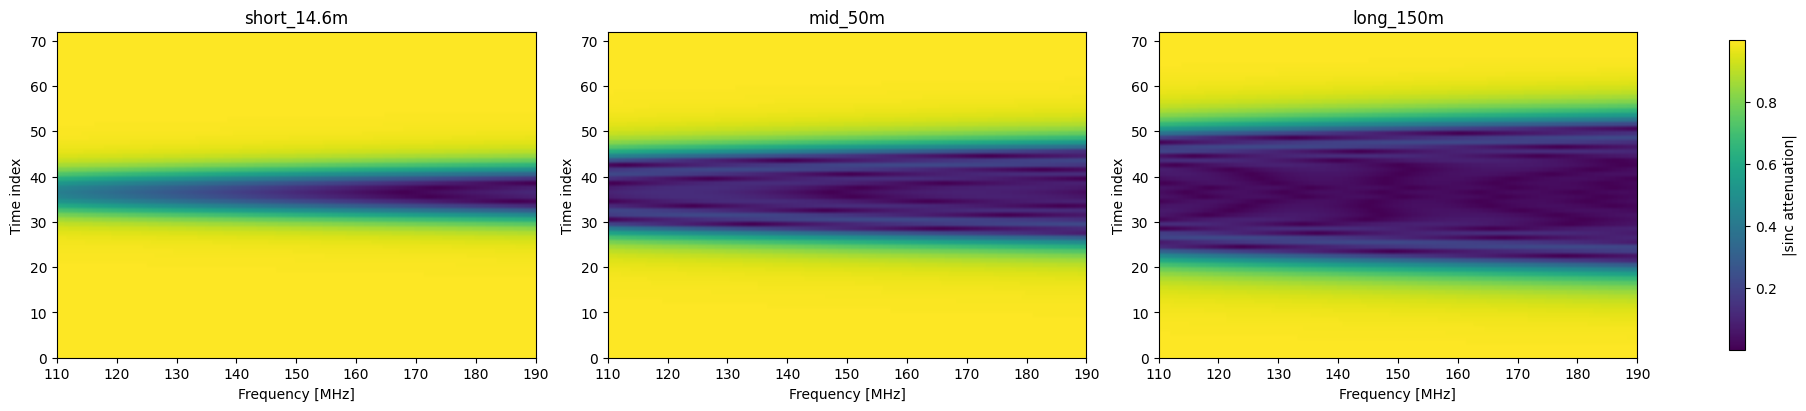

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

for ax, (name, summary) in zip(axes, summaries.items()):
    att = summary["attenuation"]
    im = ax.imshow(
        att,
        aspect="auto",
        origin="lower",
        extent=[freqs_hz.min()/1e6, freqs_hz.max()/1e6, 0, att.shape[0]],
        vmin=global_min,
        vmax=global_max,
    )
    ax.set_title(name)
    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel("Time index")

cbar = fig.colorbar(im, ax=axes, shrink=0.95)
cbar.set_label("|sinc attenuation|")
plt.show()

In [24]:
from hera_sim.beams import PolyBeam
import numpy as np
import matplotlib.pyplot as plt

# hera_sim의 PolyBeam 사용 (HERA 공식 튜토리얼 권고)
beam = PolyBeam.like_fagnoni19()
print(type(beam))

<class 'hera_sim.beams.PolyBeam'>


In [25]:
az_rad = np.deg2rad(track_vis_pass["az_deg"].to_numpy())
za_rad = np.pi / 2.0 - np.deg2rad(track_vis_pass["alt_deg"].to_numpy())

print("Ntime =", len(az_rad))
print("Nfreq =", len(freqs_hz))

Ntime = 72
Nfreq = 256


In [26]:
ef = beam.efield_eval(
    az_array=az_rad,
    za_array=za_rad,
    freq_array=freqs_hz,
)

ef = np.asarray(ef)
print("raw efield shape:", ef.shape)

def reduce_efield_to_power_tf(efield, n_time, n_freq):
    """
    efield_eval 결과를 robust하게 (Ntime, Nfreq) power beam으로 축약.
    """
    arr = np.abs(np.asarray(efield))**2

    shape = arr.shape
    time_axes = [i for i, s in enumerate(shape) if s == n_time]
    freq_axes = [i for i, s in enumerate(shape) if s == n_freq]

    if not time_axes:
        raise ValueError(f"time axis with length {n_time} not found in shape {shape}")
    if not freq_axes:
        raise ValueError(f"freq axis with length {n_freq} not found in shape {shape}")

    # 보통 time/pixel 축과 freq 축이 각각 하나씩 있을 것이라 가정
    t_ax = time_axes[-1]
    f_ax = freq_axes[0] if freq_axes[0] != t_ax else freq_axes[-1]

    arr_tf = np.moveaxis(arr, [t_ax, f_ax], [0, 1])

    # 나머지 축 평균
    if arr_tf.ndim > 2:
        extra_axes = tuple(range(2, arr_tf.ndim))
        arr_tf = arr_tf.mean(axis=extra_axes)

    return arr_tf

beam_power_tf = reduce_efield_to_power_tf(ef, len(az_rad), len(freqs_hz))

print("beam_power_tf shape:", beam_power_tf.shape)
print("beam min/max:", beam_power_tf.min(), beam_power_tf.max())

raw efield shape: (2, 2, 256, 72)
beam_power_tf shape: (72, 256)
beam min/max: 0.00032580685889553156 0.5234241435709951


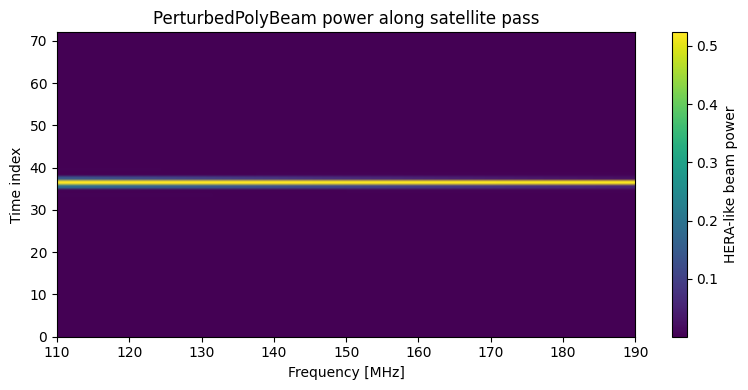

In [27]:
plt.figure(figsize=(8, 4))
plt.imshow(
    beam_power_tf,
    aspect="auto",
    origin="lower",
    extent=[freqs_hz.min()/1e6, freqs_hz.max()/1e6, 0, beam_power_tf.shape[0]],
)
plt.colorbar(label="HERA-like beam power")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Time index")
plt.title("PerturbedPolyBeam power along satellite pass")
plt.tight_layout()
plt.show()

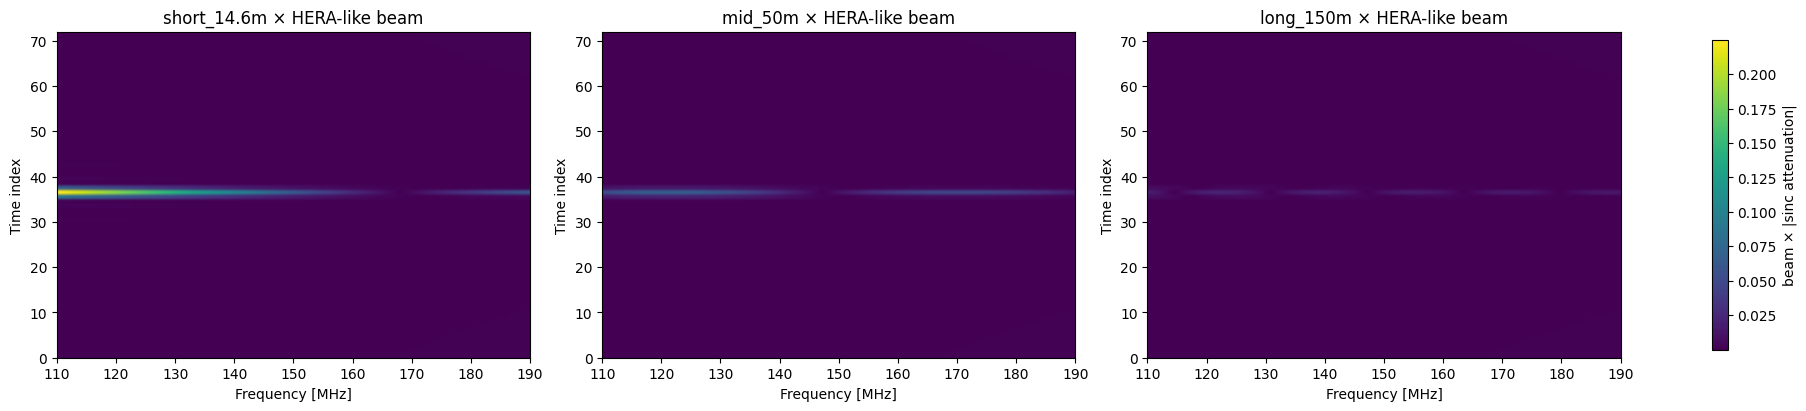

In [28]:
weighted_hlike = {}

for name, summary in summaries.items():
    att = summary["attenuation"]  # (Ntime, Nfreq)
    if att.shape != beam_power_tf.shape:
        raise ValueError(f"{name}: attenuation shape {att.shape} != beam shape {beam_power_tf.shape}")
    weighted_hlike[name] = beam_power_tf * att

global_min = min(np.min(w) for w in weighted_hlike.values())
global_max = max(np.max(w) for w in weighted_hlike.values())

fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

for ax, (name, weighted) in zip(axes, weighted_hlike.items()):
    im = ax.imshow(
        weighted,
        aspect="auto",
        origin="lower",
        extent=[freqs_hz.min()/1e6, freqs_hz.max()/1e6, 0, weighted.shape[0]],
        vmin=global_min,
        vmax=global_max,
    )
    ax.set_title(f"{name} × HERA-like beam")
    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel("Time index")

cbar = fig.colorbar(im, ax=axes, shrink=0.95)
cbar.set_label("beam × |sinc attenuation|")
plt.show()

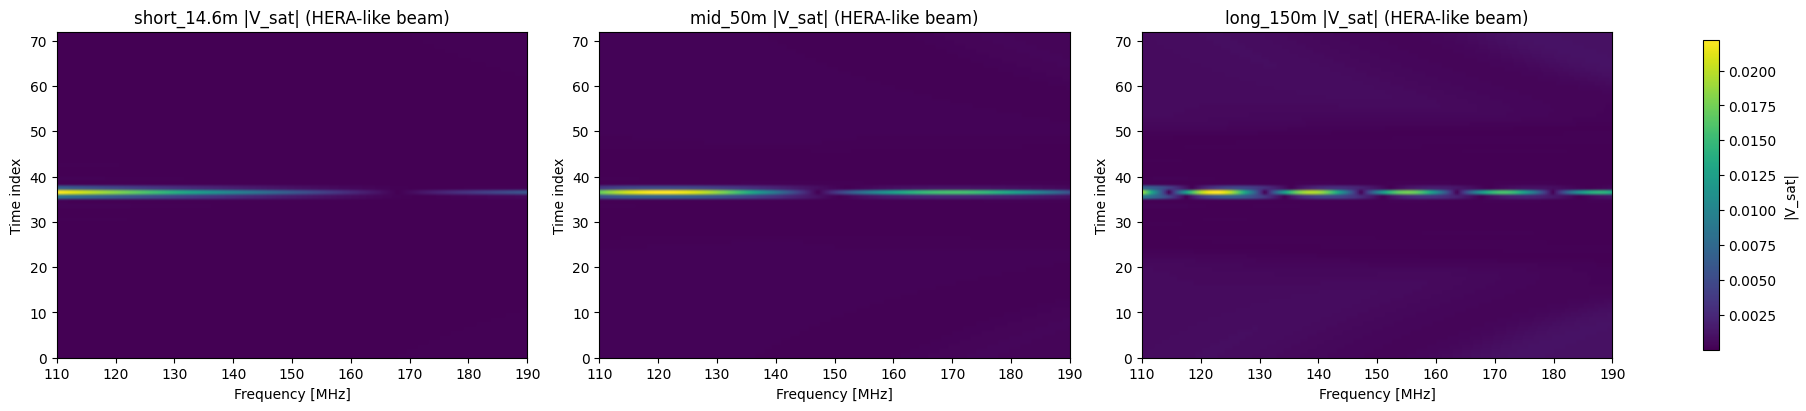

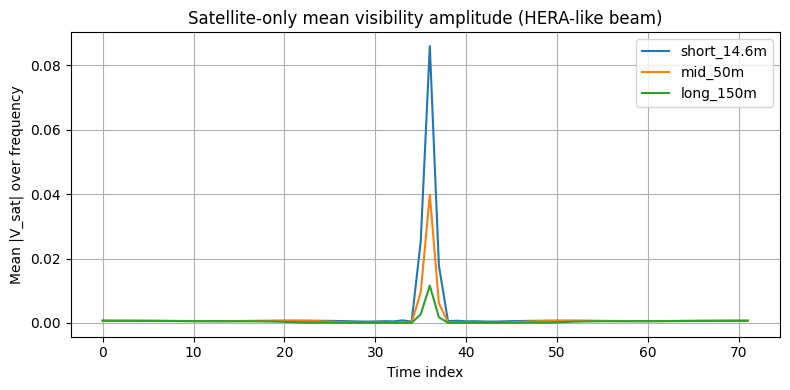

In [29]:
def flat_satellite_spectrum(freqs_hz, amp=1.0):
    return np.ones_like(freqs_hz, dtype=float) * amp

def make_satellite_only_visibility_hlike(summary, beam_power_tf, freqs_hz, amp=1.0):
    tau_s = summary["tau_s"]                    # (Ntime,)
    att = summary["attenuation"]                # (Ntime, Nfreq)
    spec = flat_satellite_spectrum(freqs_hz, amp=amp)[None, :]  # (1, Nfreq)

    phase = np.exp(-2j * np.pi * tau_s[:, None] * freqs_hz[None, :])
    vis = spec * beam_power_tf * att * phase
    return vis

sat_vis_hlike = {}
for name, summary in summaries.items():
    sat_vis_hlike[name] = make_satellite_only_visibility_hlike(
        summary=summary,
        beam_power_tf=beam_power_tf,
        freqs_hz=freqs_hz,
        amp=1.0,
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

for ax, (name, vis) in zip(axes, sat_vis_hlike.items()):
    amp = np.abs(vis)
    im = ax.imshow(
        amp,
        aspect="auto",
        origin="lower",
        extent=[freqs_hz.min()/1e6, freqs_hz.max()/1e6, 0, amp.shape[0]],
    )
    ax.set_title(f"{name} |V_sat| (HERA-like beam)")
    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel("Time index")

cbar = fig.colorbar(im, ax=axes, shrink=0.95)
cbar.set_label("|V_sat|")
plt.show()

plt.figure(figsize=(8, 4))
for name, vis in sat_vis_hlike.items():
    plt.plot(np.mean(np.abs(vis), axis=1), label=name)

plt.xlabel("Time index")
plt.ylabel("Mean |V_sat| over frequency")
plt.title("Satellite-only mean visibility amplitude (HERA-like beam)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
import numpy as np

C = 299792458.0  # m/s

def normalize_rows(xyz):
    norm = np.linalg.norm(xyz, axis=1, keepdims=True)
    return xyz / np.clip(norm, 1e-12, None)

def compute_unit_los_and_derivative(pos_enu_m, time_sec):
    """
    pos_enu_m : (Ntime, 3)
        observer -> satellite vector in ENU frame [m]
    time_sec : (Ntime,)
        time array [s]

    Returns
    -------
    s_hat : (Ntime, 3)
        line-of-sight unit vector
    ds_hat_dt : (Ntime, 3)
        time derivative of LOS unit vector [1/s]
    """
    s_hat = normalize_rows(pos_enu_m)

    ds_hat_dt = np.zeros_like(s_hat)
    for k in range(3):
        ds_hat_dt[:, k] = np.gradient(s_hat[:, k], time_sec)

    return s_hat, ds_hat_dt

def compute_fringe_rate_from_los(baseline_enu_m, ds_hat_dt, freqs_hz):
    """
    baseline_enu_m : (3,)
    ds_hat_dt : (Ntime, 3)
    freqs_hz : (Nfreq,)

    Returns
    -------
    fringe_rate_hz : (Ntime, Nfreq)
    """
    baseline_enu_m = np.asarray(baseline_enu_m, dtype=float)
    proj = ds_hat_dt @ baseline_enu_m   # (Ntime,)

    # f_fringe = - nu/c * b·ds_hat/dt
    fringe_rate_hz = -(proj[:, None] * freqs_hz[None, :]) / C
    return fringe_rate_hz

def compute_time_sinc_from_los(baseline_enu_m, pos_enu_m, time_sec, freqs_hz, dt_int_sec):
    """
    Full time-smearing attenuation from LOS evolution.
    """
    _, ds_hat_dt = compute_unit_los_and_derivative(pos_enu_m, time_sec)
    fringe_rate_hz = compute_fringe_rate_from_los(baseline_enu_m, ds_hat_dt, freqs_hz)
    sinc_time = np.sinc(fringe_rate_hz * dt_int_sec)
    return fringe_rate_hz, sinc_time

In [13]:
# quick shape sanity check for LOS-based time sinc
Ntime = 8
Nfreq = 5

time_sec = np.linspace(0.0, 7.0, Ntime)
pos_enu_m = np.stack([
    1000.0 + 3.0 * time_sec,
    2000.0 - 2.0 * time_sec,
    500.0 + 1.5 * time_sec,
], axis=1)

baseline_enu_m = np.array([14.6, 0.0, 0.0])
freqs_hz = np.linspace(100e6, 120e6, Nfreq)
dt_int_sec = 10.0

fringe_rate_hz, sinc_time = compute_time_sinc_from_los(
    baseline_enu_m=baseline_enu_m,
    pos_enu_m=pos_enu_m,
    time_sec=time_sec,
    freqs_hz=freqs_hz,
    dt_int_sec=dt_int_sec,
)

print("fringe_rate_hz shape:", fringe_rate_hz.shape)
print("sinc_time shape:", sinc_time.shape)
print("sinc min/max:", float(sinc_time.min()), float(sinc_time.max()))

fringe_rate_hz shape: (8, 5)
sinc_time shape: (8, 5)
sinc min/max: 0.9900992106644675 0.9931912384718706


In [28]:
# Combine frequency-smearing and time-smearing into attenuation_full
# Goal: make attenuation_full shape compatible with geometry_only_summary()['attenuation']

import sys
from pathlib import Path
import numpy as np
import pandas as pd

sys.path.append(str(Path("../src").resolve()))
from starlink_uemr.geometry.washing import geometry_only_summary

# Prefer real track data if available: track_df_pass -> track_df(non-empty) -> track_all -> synthetic
if all(k in globals() for k in ["track_df_pass", "baseline_enu_m", "freqs_hz", "dt_sec"]) and len(track_df_pass) >= 2:
    track_df_use = track_df_pass.copy()
    baseline_use = np.asarray(baseline_enu_m, dtype=float)
    freqs_use = np.asarray(freqs_hz, dtype=float)
    dt_use = float(dt_sec)
    print("[info] using real track_df_pass")
elif all(k in globals() for k in ["track_df", "baseline_enu_m", "freqs_hz", "dt_sec"]) and len(track_df) >= 2:
    track_df_use = track_df.copy()
    baseline_use = np.asarray(baseline_enu_m, dtype=float)
    freqs_use = np.asarray(freqs_hz, dtype=float)
    dt_use = float(dt_sec)
    print("[info] using real track_df")
elif all(k in globals() for k in ["track_all", "baseline_enu_m", "freqs_hz", "dt_sec"]) and len(track_all) >= 2:
    track_df_use = track_all.copy()
    baseline_use = np.asarray(baseline_enu_m, dtype=float)
    freqs_use = np.asarray(freqs_hz, dtype=float)
    dt_use = float(dt_sec)
    print("[info] using real track_all (track_df empty or unavailable)")
else:
    missing = [k for k in ["track_df_pass", "track_df", "track_all", "baseline_enu_m", "freqs_hz", "dt_sec"] if k not in globals()]
    print("[info] missing vars:", missing)
    print("[info] using synthetic fallback track for shape validation")

    n_time = 8
    n_freq = 5
    time_sec_syn = np.linspace(0.0, 7.0, n_time)
    pos_enu_syn = np.stack([
        1000.0 + 3.0 * time_sec_syn,
        2000.0 - 2.0 * time_sec_syn,
        500.0 + 1.5 * time_sec_syn,
    ], axis=1)

    rng_m = np.linalg.norm(pos_enu_syn, axis=1)
    uvec = pos_enu_syn / np.clip(rng_m[:, None], 1e-12, None)
    jd0 = 2460000.0
    jd = jd0 + time_sec_syn / 86400.0

    track_df_use = pd.DataFrame({
        "ux": uvec[:, 0],
        "uy": uvec[:, 1],
        "uz": uvec[:, 2],
        "range_km": rng_m / 1e3,
        "jd": jd,
        "alt_deg": np.linspace(10.0, 60.0, n_time),
        "az_deg": np.linspace(0.0, 180.0, n_time),
    })
    baseline_use = np.array([14.6, 0.0, 0.0])
    freqs_use = np.linspace(100e6, 120e6, n_freq)
    dt_use = 10.0

# 1) Reference summary with the same baseline/freq/time grid
summary_ref = geometry_only_summary(
    track_df=track_df_use,
    baseline_enu_m=baseline_use,
    freqs_hz=freqs_use,
    dt_sec=dt_use,
)

# 2) Build LOS position vector in ENU [m]
pos_enu_m = np.column_stack([
    track_df_use["ux"].to_numpy() * track_df_use["range_km"].to_numpy() * 1e3,
    track_df_use["uy"].to_numpy() * track_df_use["range_km"].to_numpy() * 1e3,
    track_df_use["uz"].to_numpy() * track_df_use["range_km"].to_numpy() * 1e3,
])

time_sec = (track_df_use["jd"].to_numpy() - track_df_use["jd"].to_numpy()[0]) * 86400.0

# 3) Time-smearing sinc: (Ntime, Nfreq)
fringe_rate_hz, sinc_time = compute_time_sinc_from_los(
    baseline_enu_m=baseline_use,
    pos_enu_m=pos_enu_m,
    time_sec=time_sec,
    freqs_hz=freqs_use,
    dt_int_sec=dt_use,
)

# 4) Frequency-smearing sinc from per-time delay and channel width
channel_width_hz = float(np.median(np.diff(freqs_use))) if len(freqs_use) > 1 else 0.0
tau_s = summary_ref["tau_s"]
sinc_freq = np.sinc(tau_s[:, None] * channel_width_hz)

# 5) Full attenuation = freq-smearing * time-smearing (element-wise)
attenuation_full = sinc_freq * sinc_time

print("summary attenuation shape:", summary_ref["attenuation"].shape)
print("sinc_time shape:", sinc_time.shape)
print("sinc_freq shape:", sinc_freq.shape)
print("attenuation_full shape:", attenuation_full.shape)

if attenuation_full.shape == summary_ref["attenuation"].shape:
    print("[ok] attenuation_full shape matches geometry_only_summary attenuation")
else:
    print("[warn] shape mismatch")

[info] using real track_df_pass
summary attenuation shape: (72, 5)
sinc_time shape: (72, 5)
sinc_freq shape: (72, 1)
attenuation_full shape: (72, 5)
[ok] attenuation_full shape matches geometry_only_summary attenuation


In [26]:
print("peak_jd:", peak_jd)
print("track_all_pass alt max 시점 jd:", 
      track_all_pass.loc[track_all_pass["alt_deg"].idxmax(), "jd"])
print("alt max:", track_all_pass["alt_deg"].max())

peak_jd: 2461131.9282354987
track_all_pass alt max 시점 jd: 2461131.9282354987
alt max: 89.39492969351522


In [30]:
print("alt range:", track_df_pass["alt_deg"].min(), 
      "~", track_df_pass["alt_deg"].max())
print("시간 범위(분):", 
      (track_df_pass["jd"].max() - track_df_pass["jd"].min()) * 1440)

alt range: 0.09617348591595282 ~ 89.39492969351522
시간 범위(분): 11.833333522081375


In [1]:
import inspect
from starlink_uemr.geometry import washing as w

print(inspect.getsource(w.delay_series_seconds))
print(inspect.getsource(w.delay_rate_series_seconds_per_second))
print(inspect.getsource(w.fringe_washing_attenuation))


ModuleNotFoundError: No module named 'starlink_uemr'